# Random Forest — SBA Loan Default Prediction

Random Forest is an ensemble learning method that builds many decision trees in parallel, each trained on a random bootstrap sample of the data and a random subset of features. Final predictions are made by majority vote across all trees.

Key strengths for this problem:
- Handles non-linear relationships and feature interactions naturally
- Built-in `class_weight="balanced"` to handle the ~17% default rate imbalance
- Provides reliable feature importance scores based on mean impurity decrease
- Robust to overfitting through averaging across many diverse trees

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve, precision_recall_curve)
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

# ── Load preprocessed data ───────────────────────────────────────────────────
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test  = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test  = pd.read_csv("../data/processed/y_test.csv").squeeze()

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Default rate — Train: {y_train.mean():.2%}, Test: {y_test.mean():.2%}")

Train: (715993, 12), Test: (178999, 12)
Default rate — Train: 17.57%, Test: 17.57%


## 1. Model Training

Random Forest trains 200 independent decision trees, each on a bootstrapped subset of the training data. At each split, only a random subset of features is considered, which decorrelates the trees and reduces variance. `class_weight="balanced"` adjusts each tree's sample weights inversely proportional to class frequency, boosting the model's sensitivity to the minority (default) class. `n_jobs=-1` enables parallel training across all available CPU cores.

In [2]:
%%time
# ── Train Random Forest ───────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,        # number of trees in the forest
    class_weight="balanced", # compensate for ~17% default rate imbalance
    random_state=42,
    n_jobs=-1                # use all CPU cores for parallel training
)

model.fit(X_train, y_train)
print("Model training complete.")

Model training complete.
CPU times: user 3min 20s, sys: 4.16 s, total: 3min 24s
Wall time: 31.2 s


## 2. Predictions

Generating hard class labels and default probability scores from the trained Random Forest ensemble.

In [3]:
# ── Generate predictions ──────────────────────────────────────────────────────
y_pred = model.predict(X_test)              # hard class labels (0 or 1)
y_prob = model.predict_proba(X_test)[:, 1]  # probability of default (class 1)

print(f"Predicted defaults: {y_pred.sum()} / {len(y_pred)} ({y_pred.mean():.2%})")
print(f"Actual defaults:    {y_test.sum()} / {len(y_test)} ({y_test.mean():.2%})")

Predicted defaults: 13476 / 178999 (7.53%)
Actual defaults:    31447 / 178999 (17.57%)


## 3. Metric Analysis

### Which metric matters most for this problem?

This is an **imbalanced classification problem** (~17% default rate), which makes metric choice critical:

| Metric | Why it matters here |
|--------|-------------------|
| **Recall** | Most important. Measures how many actual defaults we caught. Missing a default (false negative) means approving a loan that will not be repaid — a direct financial loss. |
| **ROC-AUC** | Measures the model's overall discrimination ability across all thresholds. Robust to class imbalance and useful for comparing models. |
| **PR-AUC** | Even more informative than ROC-AUC on imbalanced data — focuses specifically on the minority (default) class performance. |
| **F1 Score** | Harmonic mean of Precision and Recall. Useful when you need a single number that balances both, but does not capture the full picture. |
| **Accuracy** | **Misleading here.** A naive model that predicts "no default" for every loan would achieve ~83% accuracy — yet it would be completely useless for fraud/default detection. |

**Business context:** In SBA loan default prediction, a **false negative** (predicting "paid in full" when the loan actually defaults) is far more costly than a **false positive** (flagging a good loan as risky). Therefore, we prioritise **Recall** and **ROC-AUC** when evaluating model quality.

In [4]:
# ── Compute and display all metrics ──────────────────────────────────────────
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.4f}")
print("=" * 50)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Paid in Full", "Defaulted"]))

Accuracy:  0.8458
Precision: 0.6425
Recall:    0.2753
F1 Score:  0.3855
ROC-AUC:   0.8008

Classification Report:
              precision    recall  f1-score   support

Paid in Full       0.86      0.97      0.91    147552
   Defaulted       0.64      0.28      0.39     31447

    accuracy                           0.85    178999
   macro avg       0.75      0.62      0.65    178999
weighted avg       0.82      0.85      0.82    178999



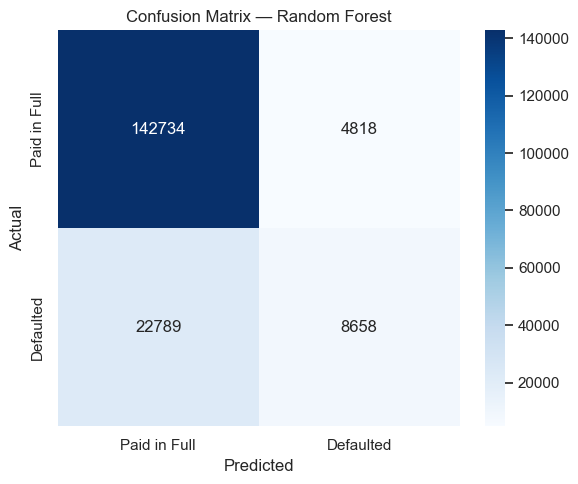

In [5]:
# ── Confusion Matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Paid in Full", "Defaulted"],
            yticklabels=["Paid in Full", "Defaulted"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — Random Forest")
plt.tight_layout()
plt.show()

# The bottom-left cell (false negatives) represents defaults the model missed.
# Minimising this cell is the primary business objective.

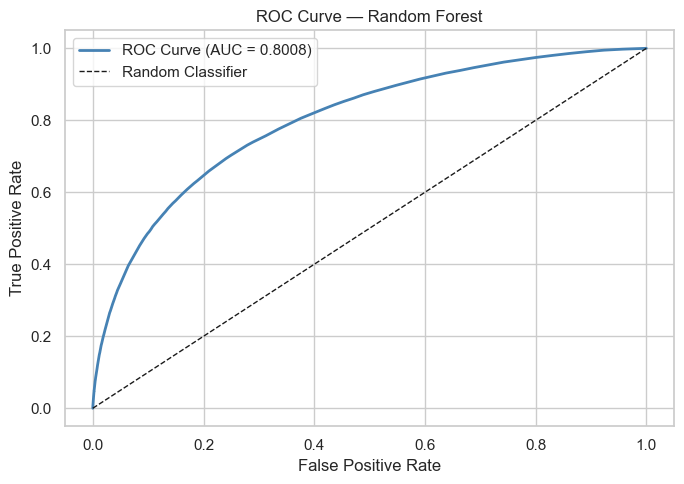

In [6]:
# ── ROC Curve ────────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color="steelblue", lw=2, label=f"ROC Curve (AUC = {auc:.4f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random Classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Random Forest")
ax.legend()
plt.tight_layout()
plt.show()

# A higher AUC means the model better separates defaults from non-defaults
# across all possible decision thresholds.

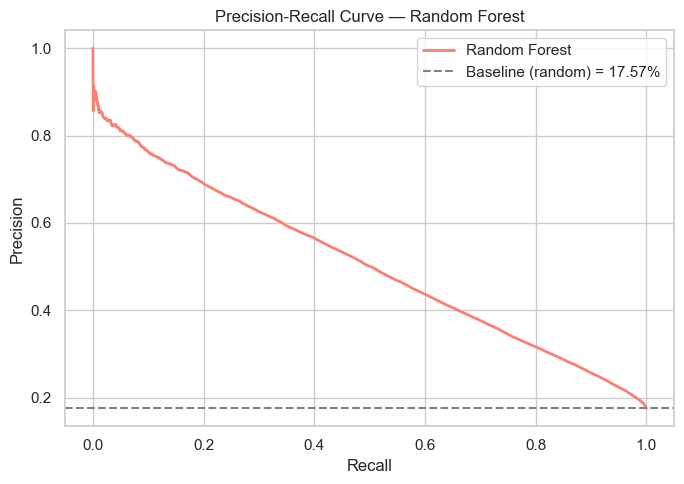

In [7]:
# ── Precision-Recall Curve ───────────────────────────────────────────────────
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall_vals, precision_vals, color="salmon", lw=2, label="Random Forest")
ax.axhline(y=y_test.mean(), color="gray", linestyle="--",
           label=f"Baseline (random) = {y_test.mean():.2%}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve — Random Forest")
ax.legend()
plt.tight_layout()
plt.show()

# The dashed baseline represents a random classifier at the observed default rate.
# A good model keeps precision well above baseline at high recall values.

## 4. Feature Importance

Random Forest computes feature importance as the mean decrease in Gini impurity across all trees and all splits where the feature was used. Features that consistently produce the cleanest splits (separating defaults from non-defaults) receive higher scores.

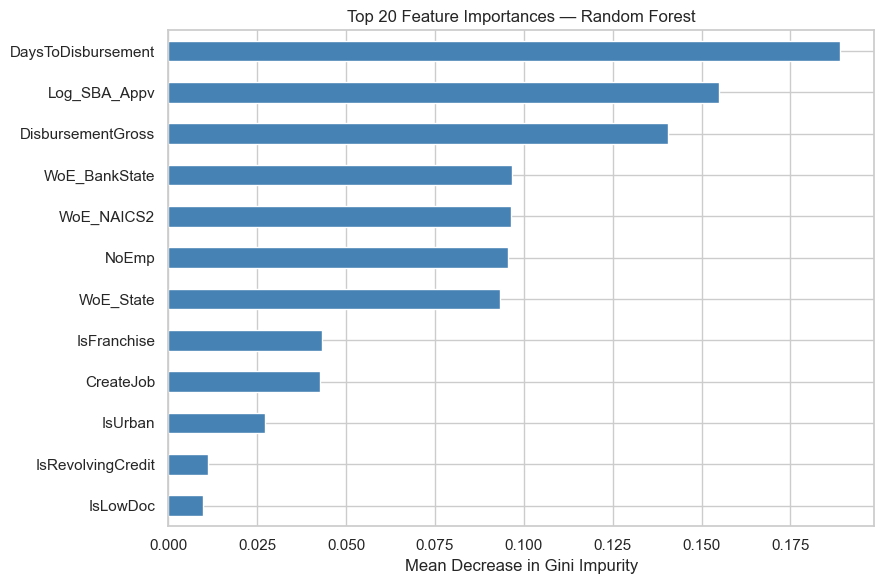

In [8]:
# ── Feature Importance bar chart ─────────────────────────────────────────────
importances = pd.Series(model.feature_importances_, index=X_train.columns)
top_20 = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 6))
top_20.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Mean Decrease in Gini Impurity")
ax.set_title("Top 20 Feature Importances — Random Forest")
plt.tight_layout()
plt.show()

# Features at the top of this chart most strongly drive the model's
# ability to distinguish loan defaults from fully repaid loans.